In [ ]:
import yaml
import numpy as np
from TraceSimulator import TraceSimulator
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from trigger_study.wk17.preliminary.OptimumFilter import *
from trigger_study.wk17.trace_IO import *


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
ts = TraceSimulator(config)



In [7]:
from TraceSimulator import LongTraceSimulator
ts = TraceSimulator(config)
trace, idx= ts.generate(
            E=50,
            no_noise=True,
            type_recoil='NR',
            quantize=True,
            phonon_only=False,
        )
trace = trace[0]

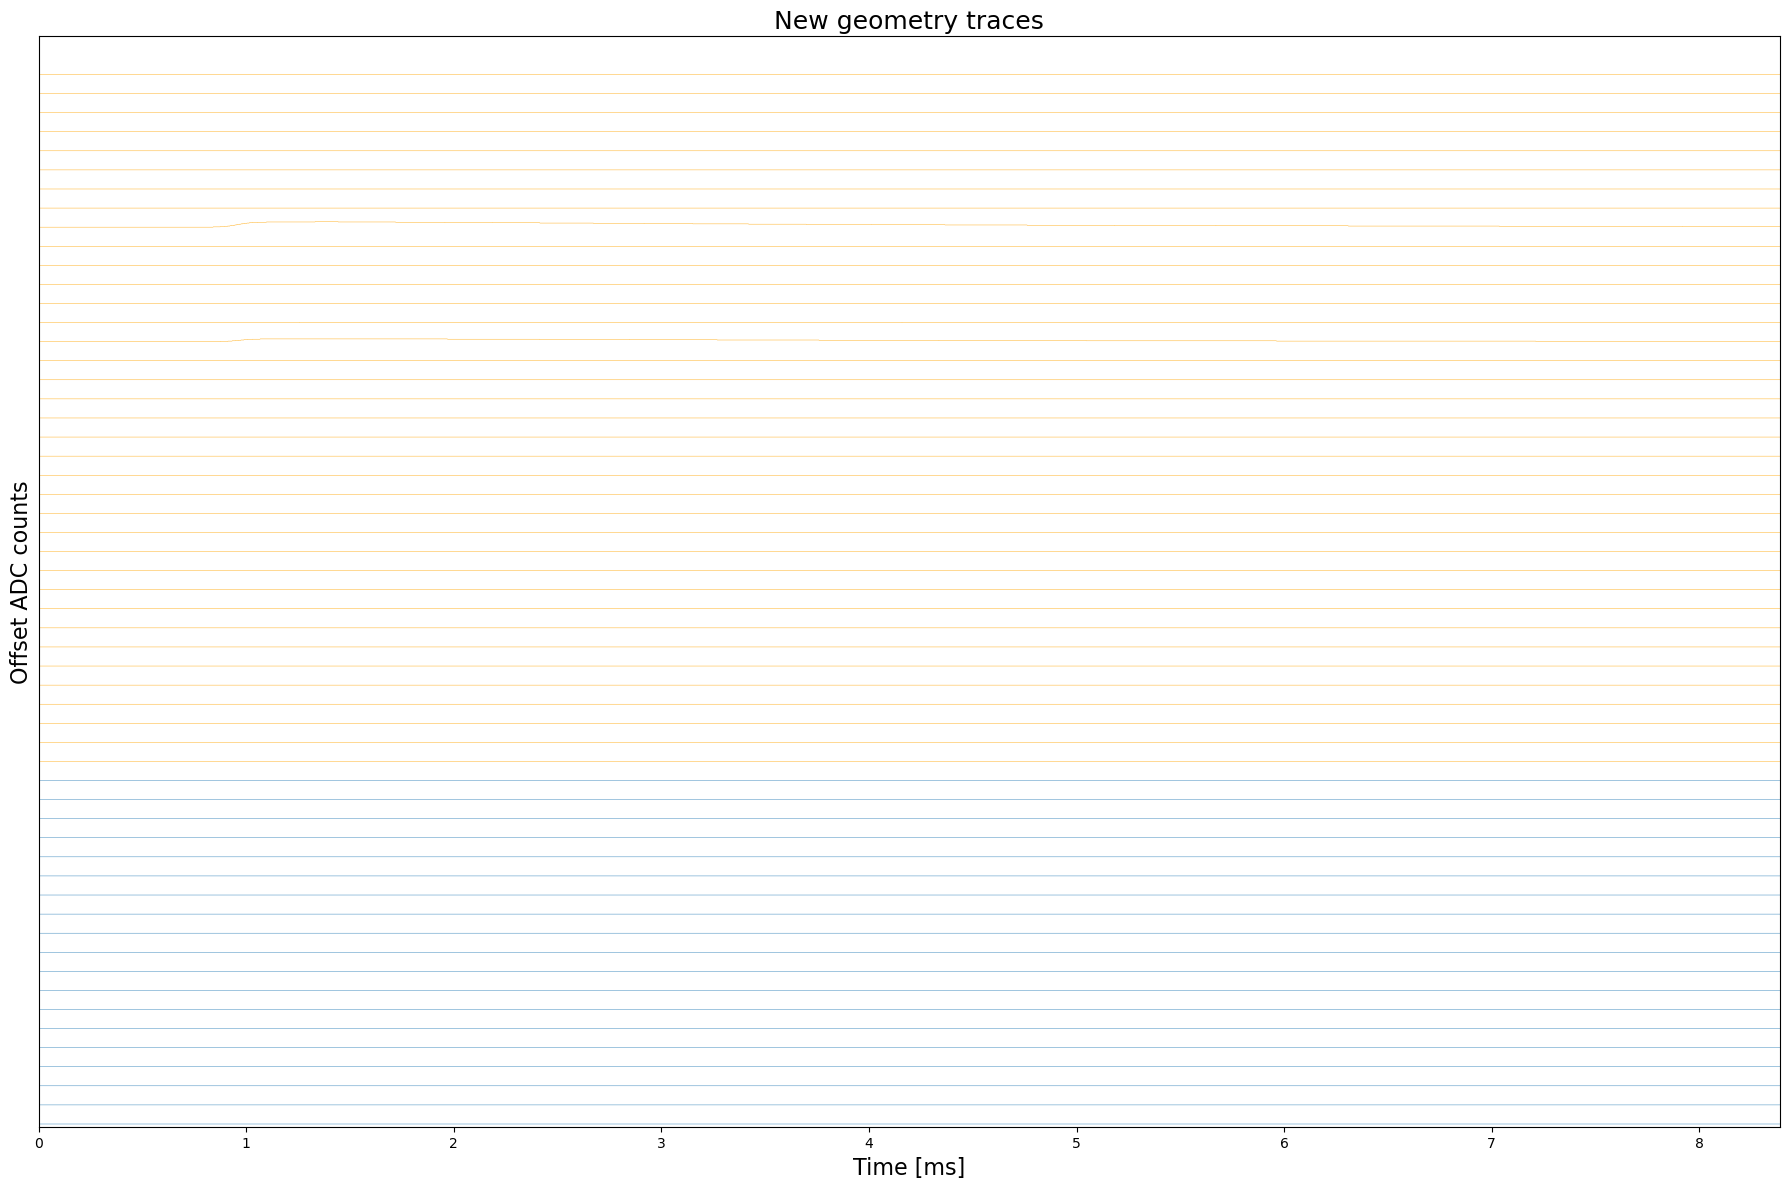

In [8]:
def plot_traces(traces, fs=3_906_250, offset_step=70, title="New geometry traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()
    
plot_traces(trace)

In [10]:
max_values = np.max(trace, axis=1)


In [11]:
max_values

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, 10,  1,  0,  0,  0,  0, 20,  0,  0,  0,
        0,  0,  0,  0,  0])

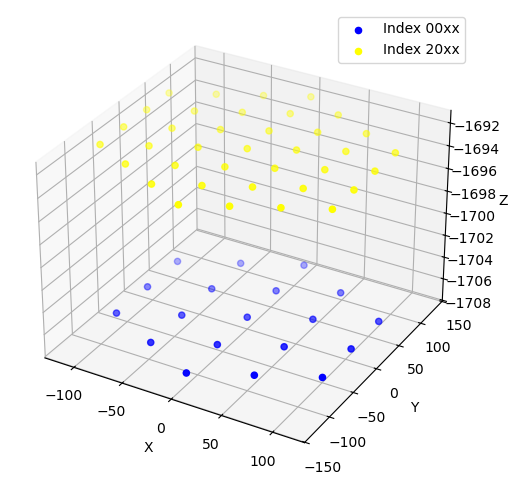

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Data pasted in directly
points = [
(0,    0.0,     0.0,     -1707.0),
(1,    52.61603,        30.37788,        -1707.0),
(2,    0.0,     60.75575,        -1707.0),
(3,    -52.61603,       30.37788,        -1707.0),
(4,    -52.61603,       -30.37788,       -1707.0),
(5,    -0.0,    -60.75575,       -1707.0),
(6,    52.61603,        -30.37788,       -1707.0),
(7,    105.23205,       0.0,     -1707.0),
(8,    105.23205,       60.75575,        -1707.0),
(9,    52.61603,        91.13363,        -1707.0),
(10,    0.0,     121.51151,       -1707.0),
(11,    -52.61603,       91.13363,        -1707.0),
(12,    -105.23205,      60.75575,        -1707.0),
(13,    -105.23205,      0.0,     -1707.0),
(14,    -105.23205,      -60.75575,       -1707.0),
(15,    -52.61603,       -91.13363,       -1707.0),
(16,    -0.0,    -121.51151,      -1707.0),
(17,    52.61603,        -91.13363,       -1707.0),
(18,    105.23205,       -60.75575,       -1707.0),

(2000, -113.97308,      -65.80239,       -1692.0),
(2001, -75.98205,       -87.73651,       -1692.0),
(2002, -37.99103,       -109.67064,      -1692.0),
(2003, 0.0,     -131.60477,      -1692.0),
(2004, -113.97308,      -21.93413,       -1692.0),
(2005, -75.98205,       -43.86826,       -1692.0),
(2006, -37.99103,       -65.80239,       -1692.0),
(2007, 0.0,     -87.73651,       -1692.0),
(2008, 37.99103,        -109.67064,      -1692.0),
(2009, -113.97308,      21.93413,        -1692.0),
(2010, -75.98205,       -0.0,    -1692.0),
(2011, -37.99103,       -21.93413,       -1692.0),
(2012, 0.0,     -43.86826,        -1692.0),
(2013, 37.99103,        -65.80239,        -1692.0),
(2014, 75.98205,        -87.73651,       -1692.0),
(2015, -113.97308,      65.80239,        -1692.0),
(2016, -75.98205,       43.86826,        -1692.0),
(2017, -37.99103,       21.93413,        -1692.0),
(2018, 0.0,     0.0,     -1692.0),
(2019, 37.99103,        -21.93413,       -1692.0),
(2020, 75.98205,        -43.86826,       -1692.0),
(2021, 113.97308,       -65.80239,       -1692.0),
(2022, -75.98205,       87.73651,        -1692.0),
(2023, -37.99103,       65.80239,        -1692.0),
(2024, -0.0,    43.86826,        -1692.0),
(2025, 37.99103,        21.93413,        -1692.0),
(2026, 75.98205,        0.0,     -1692.0),
(2027, 113.97308,       -21.93413,       -1692.0),
(2028, -37.99103,       109.67064,       -1692.0),
(2029, -0.0,    87.73651,        -1692.0),
(2030, 37.99103,        65.80239,        -1692.0),
(2031, 75.98205,        43.86826,        -1692.0),
(2032, 113.97308,       21.93413,        -1692.0),
(2033, -0.0,    131.60477,       -1692.0),
(2034, 37.99103,        109.67064,       -1692.0),
(2035, 75.98205,        87.73651,        -1692.0),
(2036, 113.97308,       65.80239,        -1692.0),
]

# Separate into groups
x0, y0, z0 = [], [], []
x2, y2, z2 = [], [], []

for idx, x, y, z in points:
    if idx<2000:
        x0.append(x); y0.append(y); z0.append(z)
    elif str(idx).startswith("2"):
        x2.append(x); y2.append(y); z2.append(z)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x0, y0, z0, c="blue", label="Index 00xx")
ax.scatter(x2, y2, z2, c="yellow", label="Index 20xx")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()
